In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv('titanic.csv')

print("--- Raw Data Sample (First 5 Rows) ---")
print(df.head())
print("\n--- Data Summary ---")
print(df.info())

--- Raw Data Sample (First 5 Rows) ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0        

In [4]:
cols_to_keep = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']
df_clean = df[cols_to_keep].copy()

# 3.2 Handle Missing Values
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 3.3 Separate Features (X) and Target (y)
X_raw = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

# 3.4 One-Hot Encoding
X = pd.get_dummies(X_raw, columns=['Sex', 'Embarked'], drop_first=True)

print("\n--- Processed Feature Matrix (Ready for AI) ---")
print(X.head())


--- Processed Feature Matrix (Ready for AI) ---
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    max_features='sqrt',  # Number of features to consider at each split
    bootstrap=True,  # Use bootstrap samples
    max_depth=5,       # Maximum depth of each tree
    random_state=42    # For reproducibility 
)

clf.fit(X_train, y_train)

print("\n--- Model Training Completed ---")



--- Model Training Completed ---


In [6]:
# ==============================================================================
# STEP 6: EVALUATION (How good is the model?)
# ==============================================================================
# Ask the model to predict the answers for the Test set
y_pred = clf.predict(X_test)

# 6.1 Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2%}") # e.g., 80.45%

# 6.2 Confusion Matrix
# Shows [True Negatives, False Positives]
#       [False Negatives, True Positives]
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# 6.3 Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 81.56%

Confusion Matrix:
[[95 10]
 [23 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



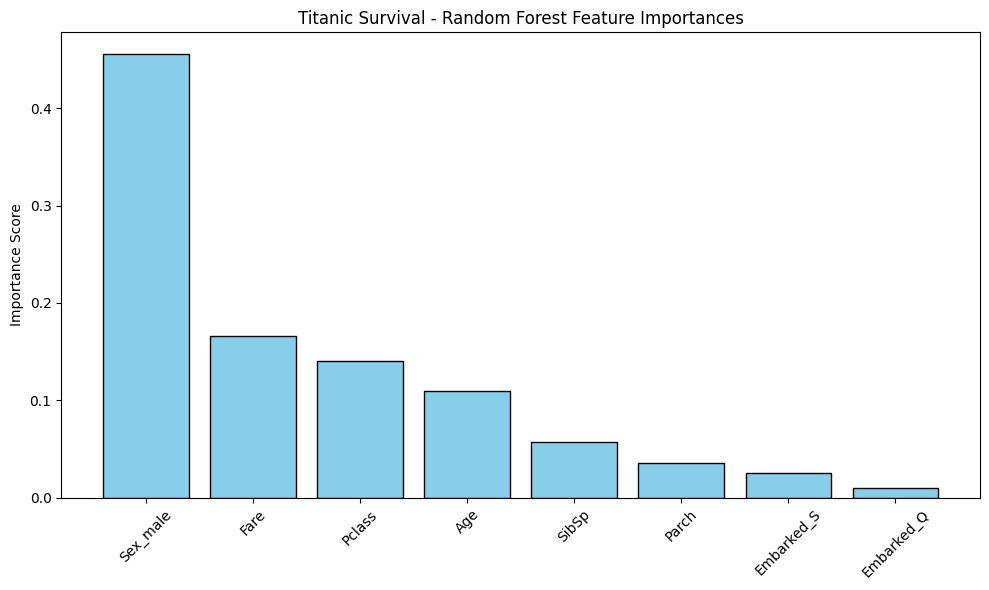

In [7]:
# ==============================================================================
# STEP 7: VISUALIZE THE MODEL (Feature Importances)
# ==============================================================================

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Titanic Survival - Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=45)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [8]:
# ==============================================================================
# STEP 8: PREDICTING AN UNKNOWN DATA SAMPLE
# ==============================================================================
# Scenario: Jack Dawson (from the movie).
# Class: 3 (Poor), Age: 20, Siblings: 0, Parents: 0, Fare: 7.25, Sex: Male, Embarked: S
print("\n--- Prediction for Unknown Sample (Jack Dawson) ---")

# We must create a new row with the EXACT same columns as the training data (X)
# 1. Create a zero-filled dictionary for all columns
jack_data = {col: 0 for col in X.columns}

# 2. Fill in Jack's details
jack_data['Pclass'] = 3
jack_data['Age'] = 20
jack_data['SibSp'] = 0
jack_data['Parch'] = 0
jack_data['Fare'] = 7.25
jack_data['Sex_male'] = 1
jack_data['Embarked_S'] = 1
jack_data['Embarked_Q'] = 0


jack_df = pd.DataFrame([jack_data]) # Convert to DataFrame

print("\nJack's Feature Data (After Encoding):")
print(jack_df)


prediction = clf.predict(jack_df) # Get the predicted class (0 or 1)
print(f"\nModel Prediction (0 = Died, 1 = Survived): {prediction[0]}")

if prediction == 1:
    print("\nPrediction: Jack Dawson would have SURVIVED.")
else:
    print("\nPrediction: Jack Dawson would have DIED.")


--- Prediction for Unknown Sample (Jack Dawson) ---

Jack's Feature Data (After Encoding):
   Pclass  Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
0       3   20      0      0  7.25         1           0           1

Model Prediction (0 = Died, 1 = Survived): 0

Prediction: Jack Dawson would have DIED.


In [19]:
# ==============================================================================
# STEP 8: PREDICTING AN UNKNOWN DATA SAMPLE
# ==============================================================================
# Scenario: Rose DeWitt Bukater
print("\n--- Prediction for Unknown Sample (Rose) ---")

# 1. Create zero-filled dictionary
rose_data = {col: 0 for col in X.columns}

# 2. Fill in Rose's details
rose_data['Pclass'] = 1
rose_data['Age'] = 17
rose_data['SibSp'] = 0
rose_data['Parch'] = 1
rose_data['Fare'] = 71.28
rose_data['Sex_male'] = 0   # Female
rose_data['Embarked_S'] = 1
rose_data['Embarked_Q'] = 0

# Convert to DataFrame
rose_df = pd.DataFrame([rose_data])

print("\nRose's Feature Data (After Encoding):")
print(rose_df)

# Prediction
prediction = clf.predict(rose_df)
print(f"\nModel Prediction (0 = Died, 1 = Survived): {prediction[0]}")

if prediction[0] == 1:
    print("\nPrediction: Rose would have SURVIVED.")
else:
    print("\nPrediction: Rose would have DIED.")


--- Prediction for Unknown Sample (Rose) ---

Rose's Feature Data (After Encoding):
   Pclass  Age  SibSp  Parch   Fare  Sex_male  Embarked_Q  Embarked_S
0       1   17      0      1  71.28         0           0           1

Model Prediction (0 = Died, 1 = Survived): 1

Prediction: Rose would have SURVIVED.
